#We build a custom multi-branch CNN with naive Inception module from scratch and train it on the Indoor Scenes CVPR 2019 dataset.

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## 1: Load image paths and labels from TrainImages.txt and TestImages.txt


In [2]:
rootDir = '/kaggle/input/indoor-scenes-cvpr-2019/indoorCVPR_09/Images'

allData = []
for label in sorted(os.listdir(rootDir)):
    labelDir = os.path.join(rootDir, label)
    if os.path.isdir(labelDir):
        for file in os.listdir(labelDir):
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                imgPath = os.path.join(labelDir, file)
                allData.append((imgPath, label))

# 80-10-10 stratified split
trainData, tempData = train_test_split(
    allData, test_size=0.2, stratify=[label for _, label in allData], random_state=42
)
valData, testData = train_test_split(
    tempData, test_size=0.5, stratify=[label for _, label in tempData], random_state=42
)

labelNames = sorted(set([label for _, label in allData]))
labelToIndex = {label: idx for idx, label in enumerate(labelNames)}
classNames = labelNames

print(f"Loaded: Train = {len(trainData)}, Val = {len(valData)}, Test = {len(testData)}")


Loaded: Train = 12496, Val = 1562, Test = 1562


## 2: Create custom PyTorch Dataset using parsed image-label pairs


In [3]:

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
trainTransform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomAffine(degrees=15, shear=10),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])





class SceneDataset(Dataset):
    def __init__(self, data, transform=None):
        self.data = data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        imgPath, label = self.data[idx]
        image = Image.open(imgPath).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, labelToIndex[label]


## 3: Create DataLoaders for training, validation, and testing


In [4]:
batchSize = 32

trainDataset = SceneDataset(trainData, trainTransform)
valDataset = SceneDataset(valData, transform)
testDataset = SceneDataset(testData, transform)

trainLoader = DataLoader(trainDataset, batch_size=batchSize, shuffle=True)
valLoader = DataLoader(valDataset, batch_size=batchSize, shuffle=False)
testLoader = DataLoader(testDataset, batch_size=batchSize, shuffle=False)

classNames = labelNames


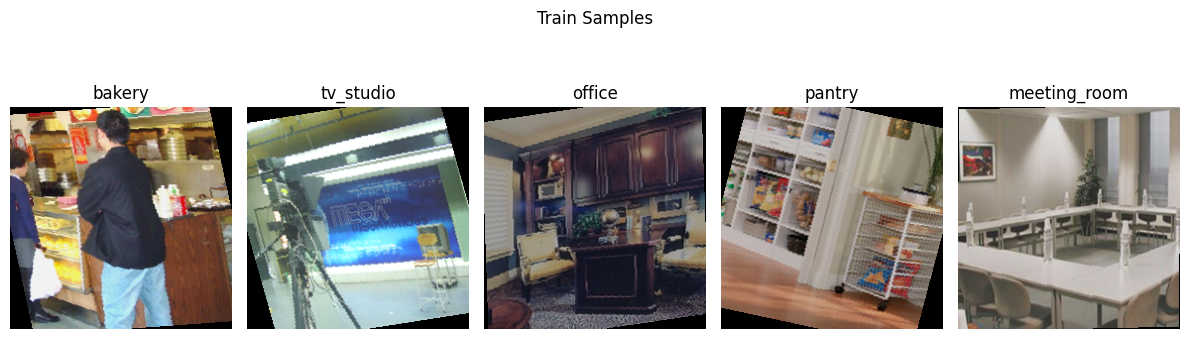

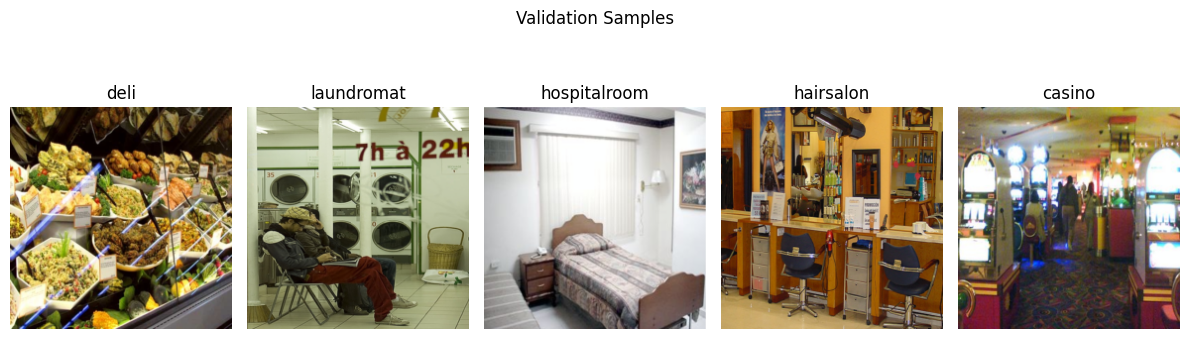

In [5]:

def showSamples(dataLoader, classNames, title="Sample Images"):
    images, labels = next(iter(dataLoader))
    plt.figure(figsize=(12, 4))
    for i in range(5):
        img = images[i].permute(1, 2, 0).numpy()  # Convert CHW → HWC
        img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])  # Unnormalize
        img = np.clip(img, 0, 1)
        plt.subplot(1, 5, i+1)
        plt.imshow(img)
        plt.title(classNames[labels[i].item()])
        plt.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

showSamples(trainLoader, classNames, title="Train Samples")
showSamples(valLoader, classNames, title="Validation Samples")


## 4: Define the custom multi-branch CNN using bottleneck Inception block


In [6]:
'''class VIGSENet(nn.Module):
    def __init__(self, num_classes=67):
        super(VIGSENet, self).__init__()

        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True)
            )

        class InceptionBlock(nn.Module):
            def __init__(self, in_channels, out_channels):
                super().__init__()
                branch1 = nn.Conv2d(in_channels, out_channels//4, 1)
                branch3 = nn.Sequential(
                    nn.Conv2d(in_channels, out_channels//4, 1),
                    nn.Conv2d(out_channels//4, out_channels//4, 3, padding=1)
                )
                branch5 = nn.Sequential(
                    nn.Conv2d(in_channels, out_channels//4, 1),
                    nn.Conv2d(out_channels//4, out_channels//4, 5, padding=2)
                )
                branch_pool = nn.Sequential(
                    nn.MaxPool2d(3, stride=1, padding=1),
                    nn.Conv2d(in_channels, out_channels//4, 1)
                )
                self.branches = nn.ModuleList([branch1, branch3, branch5, branch_pool])
                self.se = SEBlock(out_channels)

            def forward(self, x):
                outputs = [branch(x) for branch in self.branches]
                return self.se(torch.cat(outputs, 1))

        self.features = nn.Sequential(
            conv_block(3, 64),
            conv_block(64, 64),
            nn.MaxPool2d(2),

            conv_block(64, 128),
            conv_block(128, 128),
            nn.MaxPool2d(2),

            InceptionBlock(128, 256),
            nn.MaxPool2d(2),

            InceptionBlock(256, 512),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1,1)),
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)
'''

'class VIGSENet(nn.Module):\n    def __init__(self, num_classes=67):\n        super(VIGSENet, self).__init__()\n\n        def conv_block(in_c, out_c):\n            return nn.Sequential(\n                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),\n                nn.BatchNorm2d(out_c),\n                nn.ReLU(inplace=True)\n            )\n\n        class InceptionBlock(nn.Module):\n            def __init__(self, in_channels, out_channels):\n                super().__init__()\n                branch1 = nn.Conv2d(in_channels, out_channels//4, 1)\n                branch3 = nn.Sequential(\n                    nn.Conv2d(in_channels, out_channels//4, 1),\n                    nn.Conv2d(out_channels//4, out_channels//4, 3, padding=1)\n                )\n                branch5 = nn.Sequential(\n                    nn.Conv2d(in_channels, out_channels//4, 1),\n                    nn.Conv2d(out_channels//4, out_channels//4, 5, padding=2)\n                )\n                branch_pool = nn

In [6]:

class HybridEfficientCNN_MIT67(nn.Module):
    def __init__(self, num_classes=67):
        super(HybridEfficientCNN_MIT67, self).__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 64, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),  # 224 -> 112

            # Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),  # 112 -> 56

            # Block 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),  # 56 -> 28

            # SE Attention block
            SEBlock(256),

            # Block 4
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1))  # 1x1x512
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

# SE Block reused
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super(SEBlock, self).__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.shape
        se = self.pool(x).view(b, c)
        se = self.fc(se).view(b, c, 1, 1)
        return x * se


In [7]:
from torchinfo import summary

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = HybridEfficientCNN_MIT67(num_classes=67).to(device)
summary(model, input_size=(1, 3, 224, 224))


Layer (type:depth-idx)                   Output Shape              Param #
HybridEfficientCNN_MIT67                 [1, 67]                   --
├─Sequential: 1-1                        [1, 512, 1, 1]            --
│    └─Conv2d: 2-1                       [1, 64, 224, 224]         4,864
│    └─BatchNorm2d: 2-2                  [1, 64, 224, 224]         128
│    └─ReLU: 2-3                         [1, 64, 224, 224]         --
│    └─MaxPool2d: 2-4                    [1, 64, 112, 112]         --
│    └─Conv2d: 2-5                       [1, 128, 112, 112]        73,856
│    └─ReLU: 2-6                         [1, 128, 112, 112]        --
│    └─Conv2d: 2-7                       [1, 128, 112, 112]        147,584
│    └─BatchNorm2d: 2-8                  [1, 128, 112, 112]        256
│    └─ReLU: 2-9                         [1, 128, 112, 112]        --
│    └─MaxPool2d: 2-10                   [1, 128, 56, 56]          --
│    └─Conv2d: 2-11                      [1, 256, 56, 56]          295,

5: Setup device, loss function, optimizer, LR scheduler, and early stopping

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = HybridEfficientCNN_MIT67(num_classes=67).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=5e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)
earlyStopPatience = 7
batchSize = 64


In [9]:
import time

def trainModel(model, trainLoader, valLoader, criterion, optimizer, scheduler, epochs=60, earlyStopPatience=5):
    bestValAcc = 0
    patienceCounter = 0

    trainAccList, valAccList, trainLossList, valLossList = [], [], [], []

    for epoch in range(epochs):
        start_time = time.time()

        model.train()
        totalTrainLoss, correctTrain, totalTrain = 0, 0, 0

        for images, labels in trainLoader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            totalTrainLoss += loss.item()
            _, preds = outputs.max(1)
            correctTrain += (preds == labels).sum().item()
            totalTrain += labels.size(0)

        trainAcc = correctTrain / totalTrain
        trainLoss = totalTrainLoss / len(trainLoader)

        valLoss, valAcc = evaluateModel(model, valLoader, criterion)

        trainAccList.append(trainAcc)
        valAccList.append(valAcc)
        trainLossList.append(trainLoss)
        valLossList.append(valLoss)

        scheduler.step()

        elapsed_time = time.time() - start_time
        print(f"Current LR: {scheduler.get_last_lr()[0]:.6f}")
        print(f"Epoch {epoch+1:02d} | Train Acc: {trainAcc:.4f} | Val Acc: {valAcc:.4f} | "
              f"Train Loss: {trainLoss:.4f} | Val Loss: {valLoss:.4f} | Time: {elapsed_time:.2f}s")

        if valAcc > bestValAcc:
            bestValAcc = valAcc
            patienceCounter = 0
            torch.save(model.state_dict(), "bestModel.pth")
        else:
            patienceCounter += 1
            if patienceCounter >= earlyStopPatience:
                print("Early stopping triggered.")
                break

    return trainAccList, valAccList, trainLossList, valLossList


In [10]:

def evaluateModel(model, dataLoader, criterion):
    model.eval()
    totalLoss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in dataLoader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            totalLoss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avgLoss = totalLoss / len(dataLoader)
    accuracy = correct / total
    return avgLoss, accuracy

In [11]:
trainAccList, valAccList, trainLossList, valLossList = trainModel(
    model, trainLoader, valLoader, criterion, optimizer, scheduler,
    epochs=60, earlyStopPatience=5
)


Current LR: 0.000200
Epoch 01 | Train Acc: 0.0855 | Val Acc: 0.1191 | Train Loss: 3.8728 | Val Loss: 3.6667 | Time: 346.79s
Current LR: 0.000200
Epoch 02 | Train Acc: 0.1063 | Val Acc: 0.1511 | Train Loss: 3.7202 | Val Loss: 3.5526 | Time: 245.90s
Current LR: 0.000200
Epoch 03 | Train Acc: 0.1269 | Val Acc: 0.1421 | Train Loss: 3.6337 | Val Loss: 3.5364 | Time: 245.17s
Current LR: 0.000199
Epoch 04 | Train Acc: 0.1492 | Val Acc: 0.1908 | Train Loss: 3.5465 | Val Loss: 3.3599 | Time: 251.50s
Current LR: 0.000199
Epoch 05 | Train Acc: 0.1636 | Val Acc: 0.2241 | Train Loss: 3.4691 | Val Loss: 3.2356 | Time: 250.08s
Current LR: 0.000198
Epoch 06 | Train Acc: 0.1870 | Val Acc: 0.2234 | Train Loss: 3.3875 | Val Loss: 3.2556 | Time: 241.71s
Current LR: 0.000198
Epoch 07 | Train Acc: 0.1982 | Val Acc: 0.2529 | Train Loss: 3.3332 | Val Loss: 3.1064 | Time: 239.83s
Current LR: 0.000197
Epoch 08 | Train Acc: 0.2185 | Val Acc: 0.2657 | Train Loss: 3.2652 | Val Loss: 3.0376 | Time: 243.48s
Current 

In [ ]:
from IPython.display import FileLink
FileLink('/kaggle/working/best_model.pth')


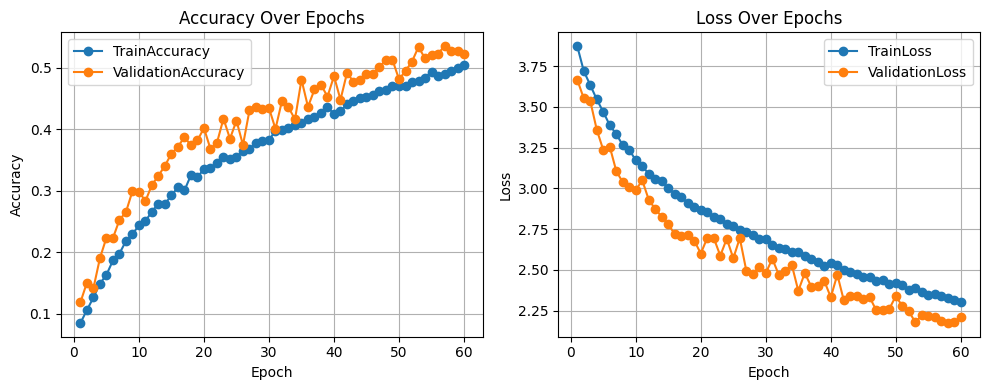

In [12]:
import matplotlib.pyplot as plt

def plotAccuracyLoss(trainAccList, valAccList, trainLossList, valLossList):
    Epochs = range(1, len(trainAccList) + 1)

    # Accuracy Plot
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(Epochs, trainAccList, label='TrainAccuracy', marker='o')
    plt.plot(Epochs, valAccList, label='ValidationAccuracy', marker='o')
    plt.title('Accuracy Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(Epochs, trainLossList, label='TrainLoss', marker='o')
    plt.plot(Epochs, valLossList, label='ValidationLoss', marker='o')
    plt.title('Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plotAccuracyLoss(trainAccList, valAccList, trainLossList, valLossList)


In [13]:

def evaluateModel(model, dataLoader, criterion):
    model.eval()
    totalLoss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in dataLoader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            totalLoss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avgLoss = totalLoss / len(dataLoader)
    accuracy = correct / total
    return avgLoss, accuracy

In [14]:
model.load_state_dict(torch.load("bestModel.pth"))
testLoss, testAcc = evaluateModel(model, testLoader, criterion)
print(f"Test Accuracy: {testAcc:.4f} | Test Loss: {testLoss:.4f}")

Test Accuracy: 0.5192 | Test Loss: 2.2049


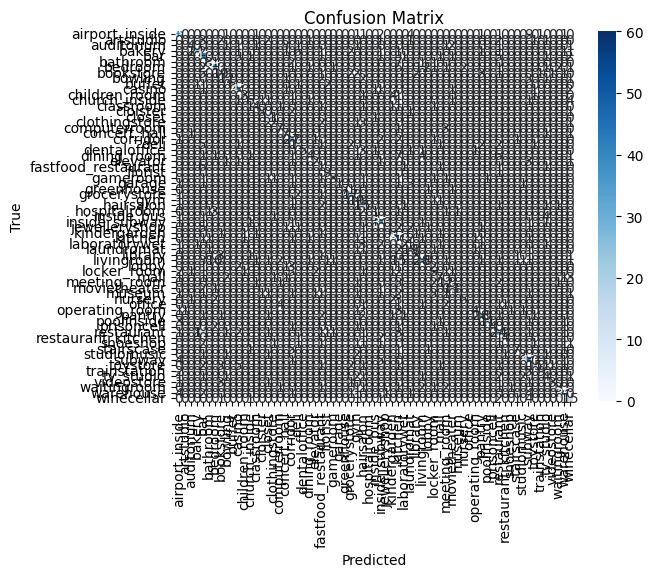

                     precision    recall  f1-score   support

     airport_inside       0.56      0.62      0.59        61
          artstudio       0.00      0.00      0.00        14
         auditorium       0.50      0.24      0.32        17
             bakery       0.88      0.51      0.65        41
                bar       0.39      0.67      0.49        61
           bathroom       0.62      0.40      0.48        20
            bedroom       0.62      0.48      0.54        66
          bookstore       0.58      0.50      0.54        38
            bowling       0.60      0.55      0.57        22
             buffet       1.00      0.55      0.71        11
             casino       0.72      0.84      0.77        51
      children_room       0.50      0.27      0.35        11
      church_inside       0.46      0.33      0.39        18
          classroom       0.44      0.36      0.40        11
           cloister       0.80      0.67      0.73        12
             closet    

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [15]:
allLabels, allPreds = [], []
model.eval()
with torch.no_grad():
    for images, labels in testLoader:
        images = images.to(device)
        outputs = model(images)
        _, preds = outputs.max(1)
        allLabels.extend(labels.cpu().numpy())
        allPreds.extend(preds.cpu().numpy())

cm = confusion_matrix(allLabels, allPreds)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classNames, yticklabels=classNames, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(allLabels, allPreds, target_names=classNames))

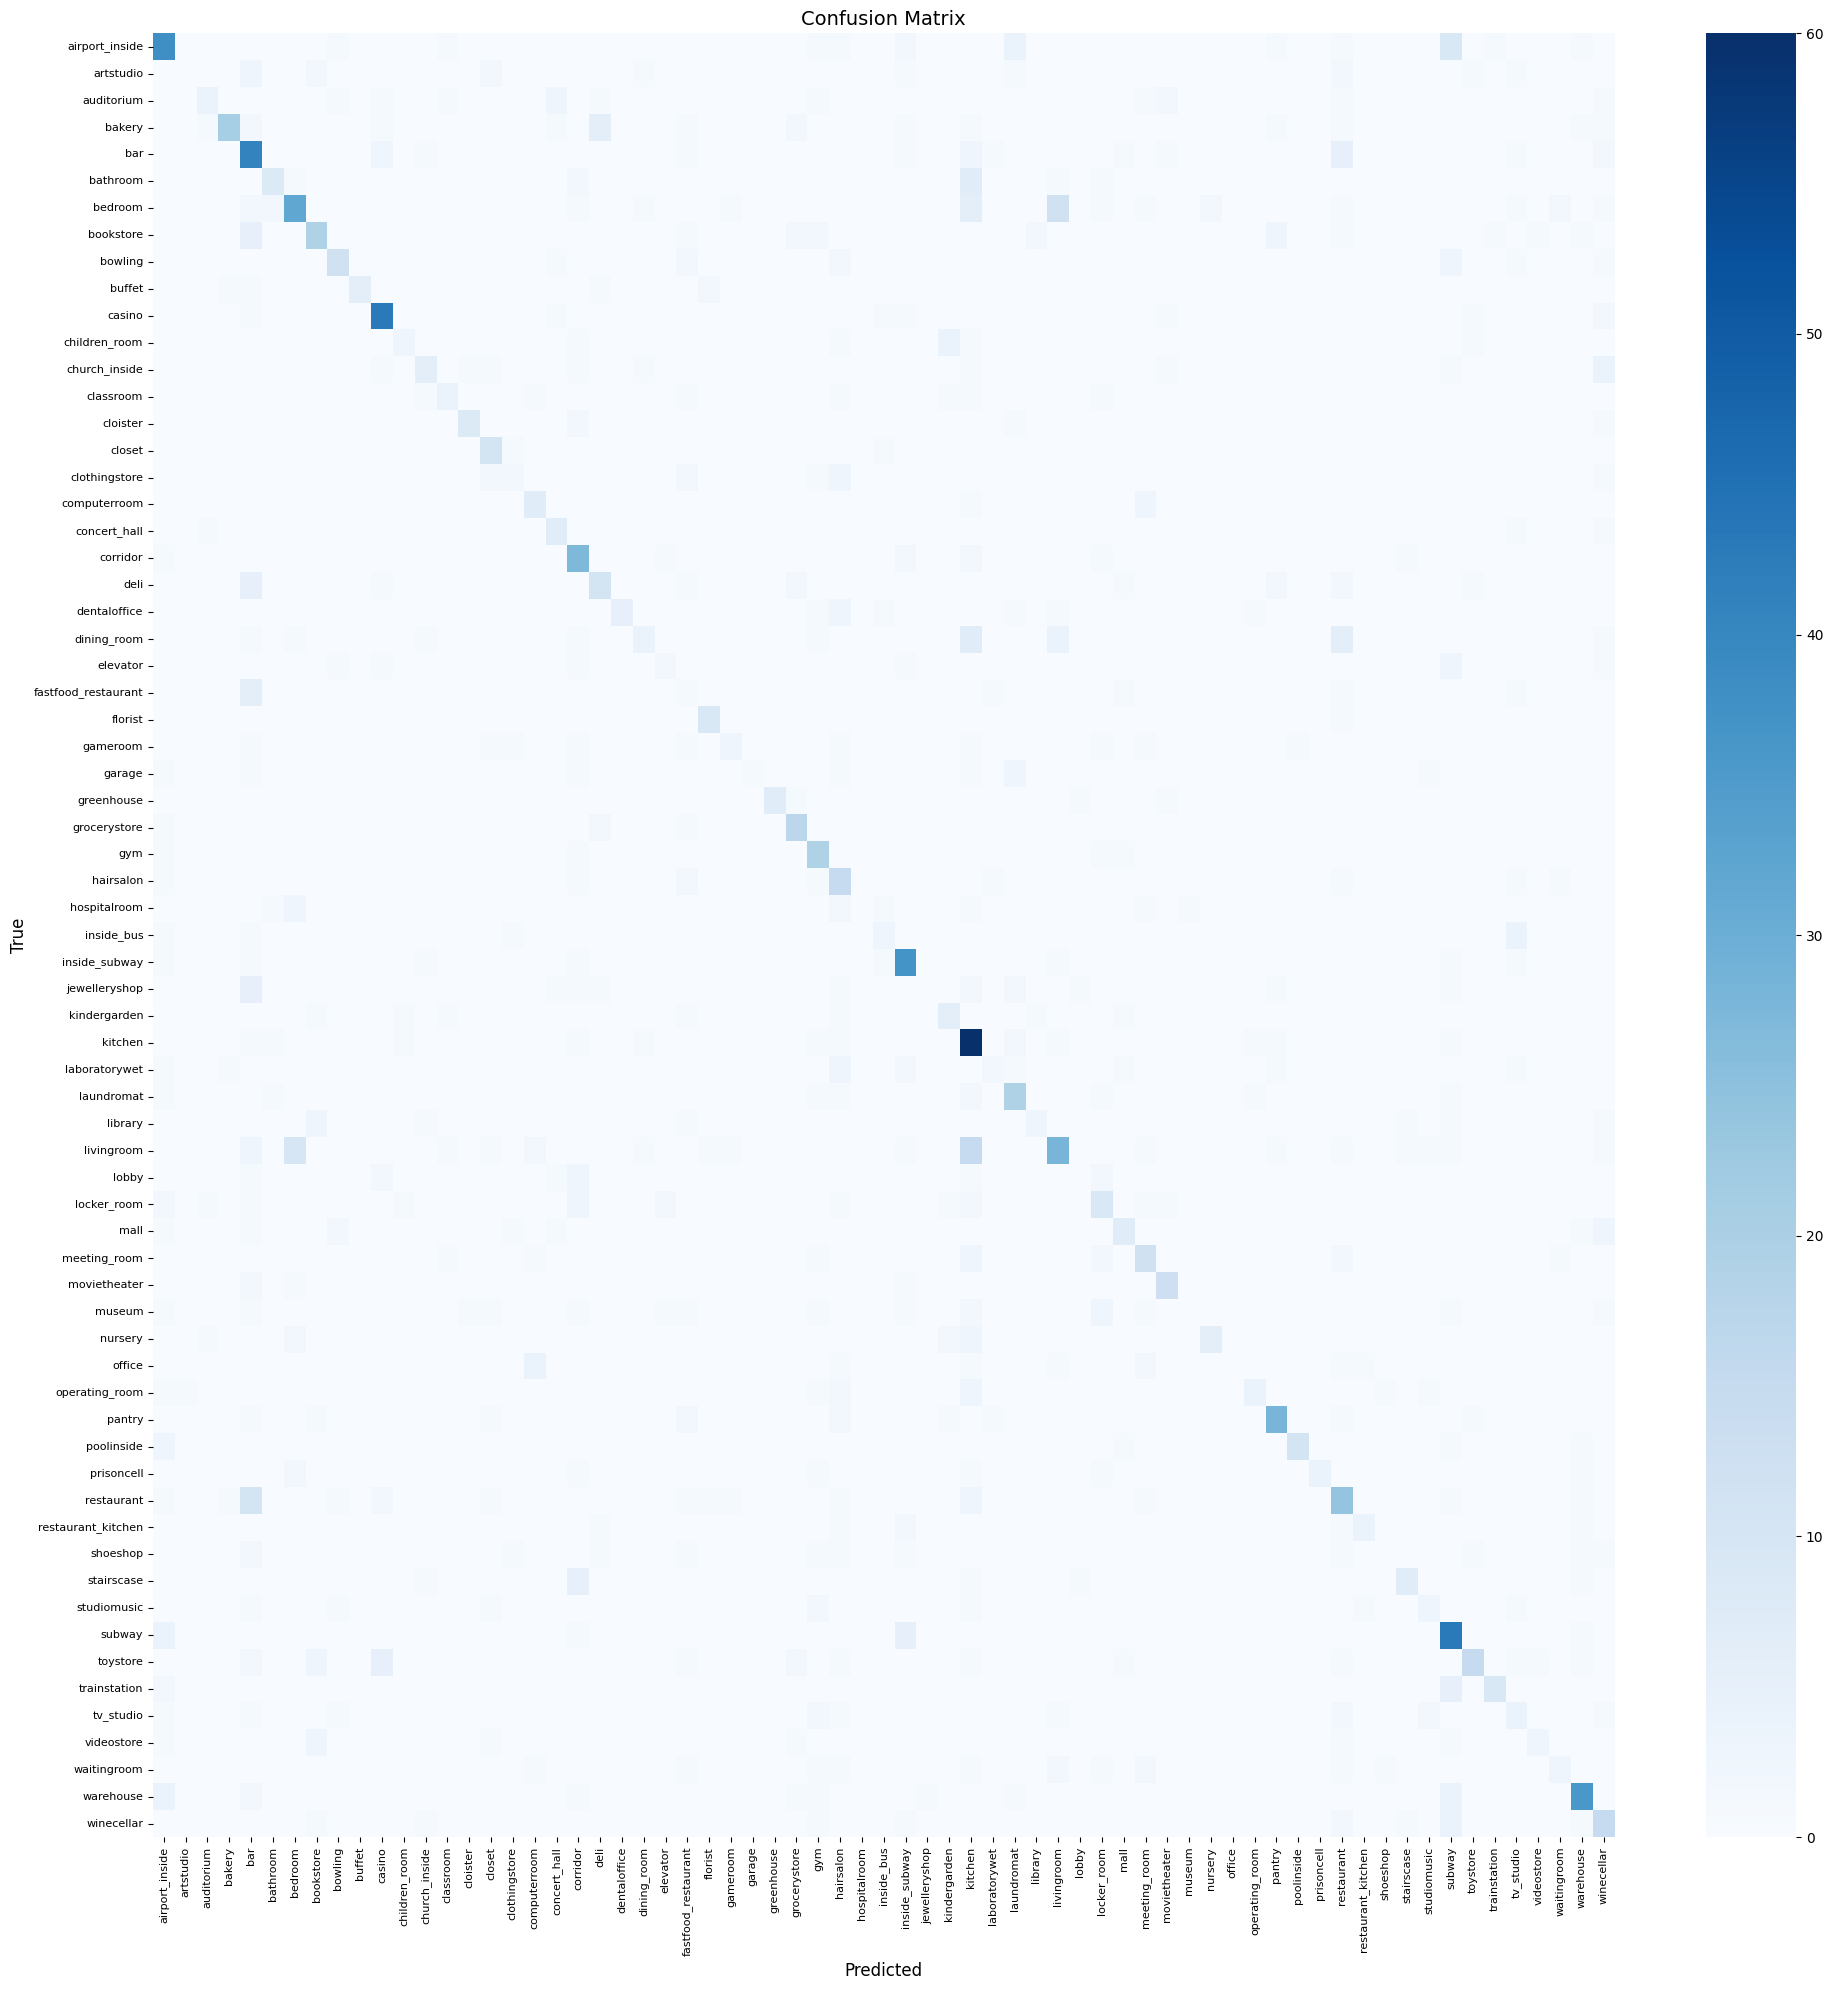

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Compute confusion matrix
cm = confusion_matrix(allLabels, allPreds)

# Set figure size to avoid label overlap
plt.figure(figsize=(20, 20))

# Plot the heatmap with no annotations to keep it clean
sns.heatmap(cm, cmap='Blues', xticklabels=classNames, yticklabels=classNames)

plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("True", fontsize=12)
plt.title("Confusion Matrix", fontsize=14)
plt.tight_layout()
plt.show()
